## Start Set-Up
Before starting the code, you need to make sure to have the datasets loaded.
- Run the code block bellow which should download the datasets and put them in the right folder

Then I recommend switching your google colab to TPU for improved performance
- At the top right, you should see the Ram and disc
- Click on it
- At the bottom right, click on change runtime type
- Change to TPU or GPU



In [10]:
# import kagglehub
# path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

## Imports

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms # Import transforms
import torchvision.datasets as datasets # Import datasets
import torchvision.models as models # Import models
import numpy as np

import cv2
from matplotlib import pyplot as plt

from PIL import Image, ImageEnhance
import torchvision.models as models # Import models
import torch.nn.functional as F
import matplotlib.pyplot as plt
import os
from torch.utils.data import DataLoader

import gradio as gr


## Config variables 

In [22]:
SAVED_MODEL_PATH = os.path.join("DenseNet121model_prototype.pth")

# Training Settings
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 5
LEARNING_RATE = 1e-4

# Data Paths
DATA_ROOT = os.path.join("chest_xray" , "chest_xray")
TRAIN_PATH = os.path.join(DATA_ROOT, "train")
VAL_PATH = os.path.join(DATA_ROOT, "val")
TEST_PATH = os.path.join(DATA_ROOT, "test")

test_image = os.path.join("test_images", "14f8c2fcbb4c6f58f82914e6e6b7462896914811-3537x2831.jpg")
test_image1 = os.path.join("test_images", "NORMAL2-IM-0361-0001.jpeg")
test_image2 = os.path.join("test_images", "NORMAL2-IM-0368-0001.jpeg")
test_image3 = os.path.join("test_images", "NORMAL2-IM-0378-0001.jpeg")
test_image4 = os.path.join("test_images", "person1655_virus_2861.jpeg")
test_image5 = os.path.join("test_images", "person1662_virus_2875.jpeg")
test_image6 = os.path.join("test_images", "person1669_virus_2885.jpeg")
test_image7 = os.path.join("test_images", "person1678_virus_2895.jpeg")


## Model Training

In [ ]:
def UpdateTransform():
    return transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomHorizontalFlip(),
    # Added a random vertical flip to the dataset
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

transform = UpdateTransform()
fixed_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
])

# Load dataset folders
train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=transform)
val_dataset = datasets.ImageFolder(root=VAL_PATH, transform=fixed_transform)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=fixed_transform)

# Create loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

#Load neural network
model = models.densenet121(pretrained=True) 
#model.fc = nn.Linear(model.fc.in_features, 2)

#Moves workload to GPU if available, else CPU
try:
    import torch_xla.core.xla_model as xm
    device = xm.xla_device()
    print("Using TPU")
except ImportError:
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print("Using GPU")
    else:
        device = torch.device("cpu")
        print("Using CPU")

model = model.to(device)

#Accuracy criteria
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

def TrainModel():
  #Trains on entire dataset for x different iterations
  num_epochs = NUM_EPOCHS
  #Training loop
  for epoch in range(num_epochs):
      #Sets model to train, running_loss keeps track of accuracy
      model.train()
      running_loss = 0.0
      iteration_count = 0

      if (epoch + 1) % 10 == 0:
            transform = UpdateTransform()
            train_dataset.transform = transform

      for images, labels in train_loader:
          images = images.to(device)
          labels = labels.to(device)

          optimizer.zero_grad()
          outputs = model(images)
          loss = criterion(outputs, labels)
          loss.backward()
          if 'torch_xla' in globals() and isinstance(device, type(xm.xla_device())):
              xm.optimizer_step(optimizer)
              xm.mark_step()
          else:
              optimizer.step()

          running_loss += loss.item()
          iteration_count += 1
      print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
      ValidateModel(val_loader)

def ValidateModel(loader_set):
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
      for images, labels in loader_set:
          images = images.to(device)
          labels = labels.to(device)
          outputs = model(images)
          _, predicted = torch.max(outputs.data, 1)
          total += labels.size(0)
          correct += (predicted == labels).sum().item()

  print(f'Validation Accuracy: {100 * correct / total:.2f}%')


if __name__ == "__main__":
  ValidateModel(test_loader)
  TrainModel()
  ValidateModel(test_loader)
  torch.save(model.state_dict(), "DenseNet121model_prototype.pth")
  print("Model saved")

## CLAHE Saturation

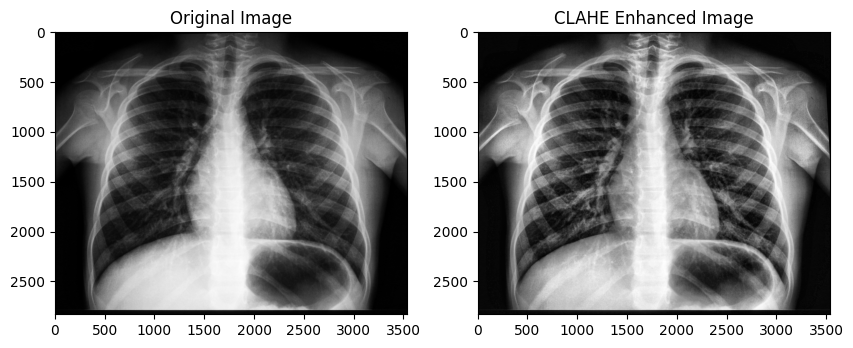

In [19]:
# Load image in grayscale
img = cv2.imread(test_image, cv2.IMREAD_GRAYSCALE)

# Create CLAHE object
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# Apply CLAHE to the image
cl1 = clahe.apply(img)

# Display original and enhanced images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.subplot(1,2,2)
plt.title('CLAHE Enhanced Image')
plt.imshow(cl1, cmap='gray')
plt.show()


## Heat Mapping

NORMAL: 2.80%
PNEUMONIA: 97.13%
Predicted: PNEUMONIA with confidence 97.13%


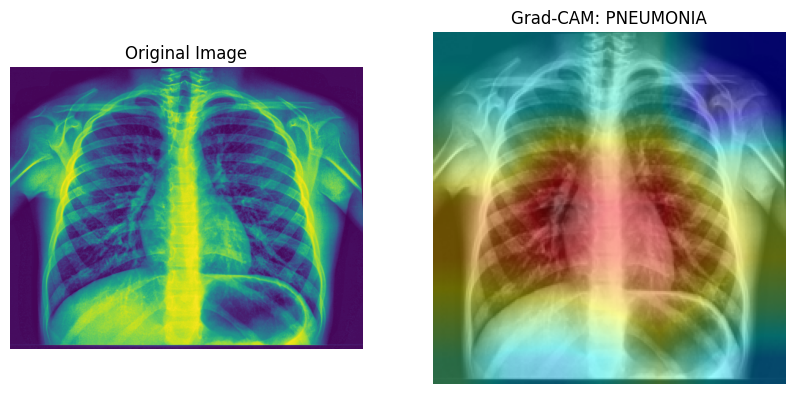

NORMAL: 16.68%
PNEUMONIA: 83.18%
Predicted: PNEUMONIA with confidence 83.18%


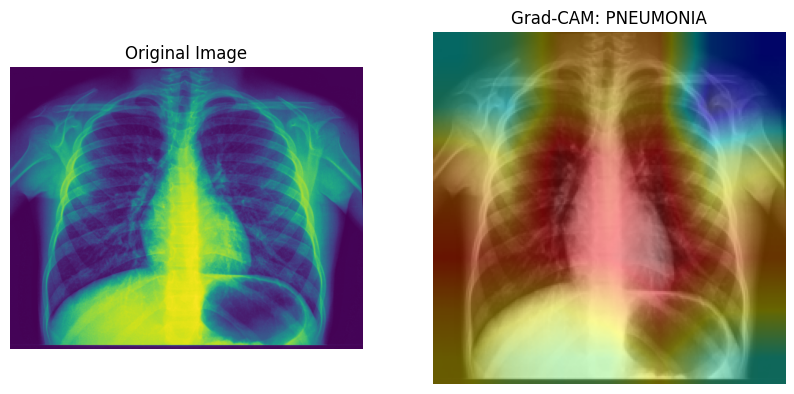

NORMAL: 0.18%
PNEUMONIA: 99.79%
Predicted: PNEUMONIA with confidence 99.79%


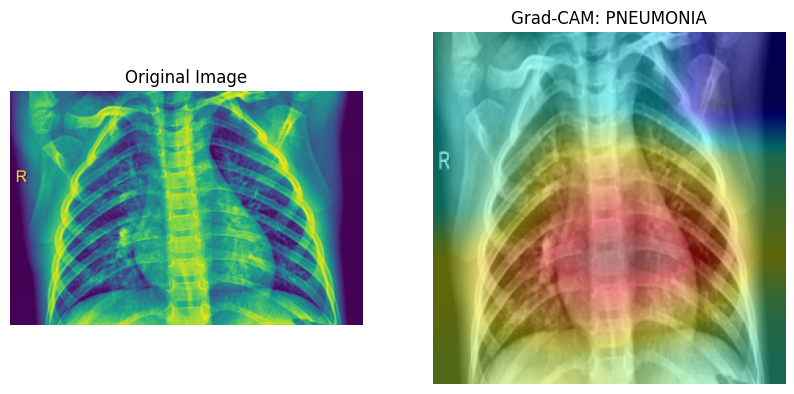

NORMAL: 18.48%
PNEUMONIA: 81.47%
Predicted: PNEUMONIA with confidence 81.47%


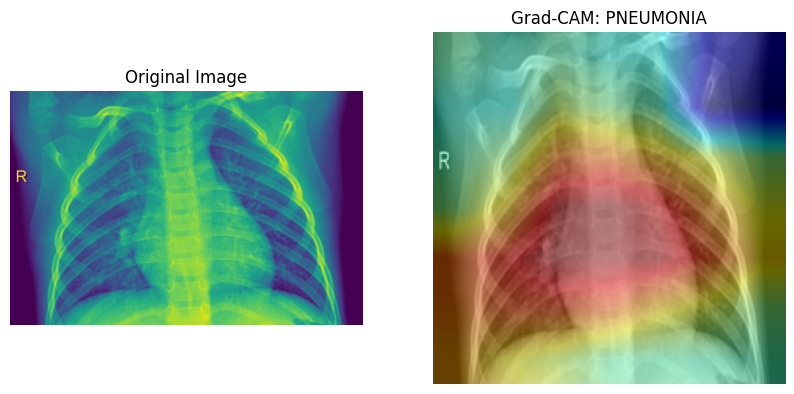

NORMAL: 0.02%
PNEUMONIA: 99.96%
Predicted: PNEUMONIA with confidence 99.96%


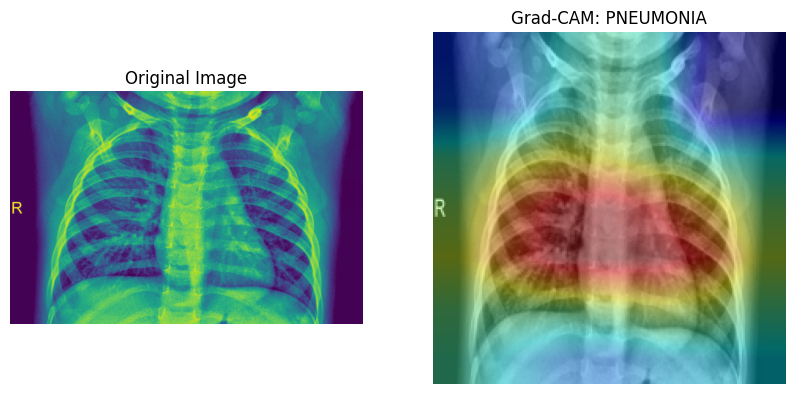

NORMAL: 21.77%
PNEUMONIA: 78.10%
Predicted: PNEUMONIA with confidence 78.10%


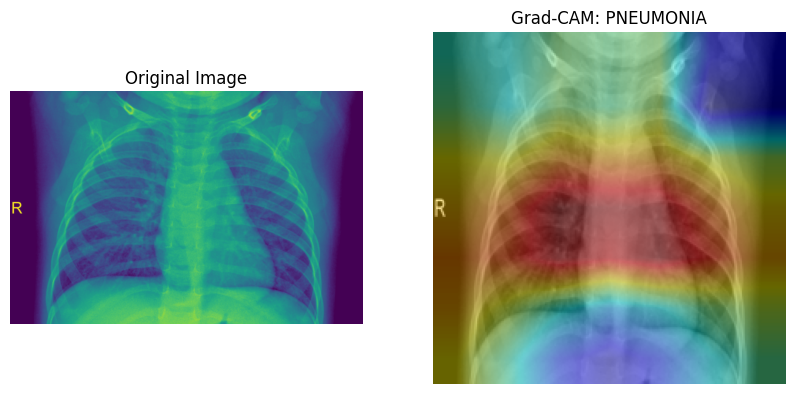

NORMAL: 4.14%
PNEUMONIA: 95.81%
Predicted: PNEUMONIA with confidence 95.81%


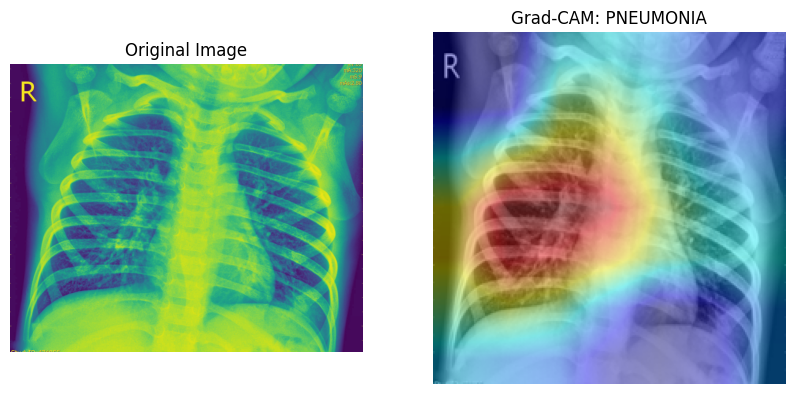

NORMAL: 5.17%
PNEUMONIA: 94.78%
Predicted: PNEUMONIA with confidence 94.78%


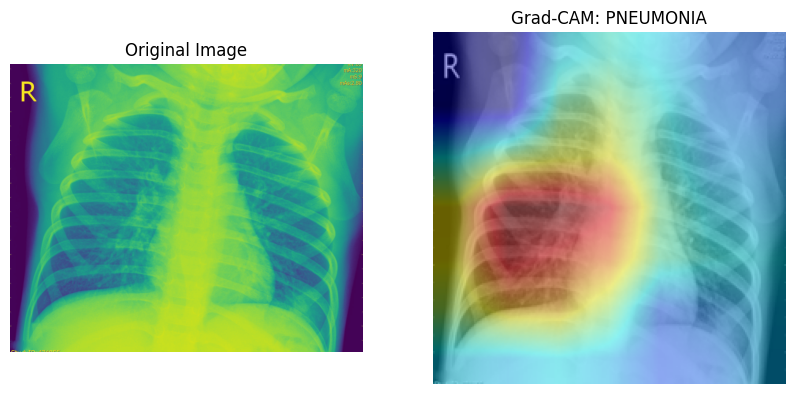

NORMAL: 0.00%
PNEUMONIA: 100.00%
Predicted: PNEUMONIA with confidence 100.00%


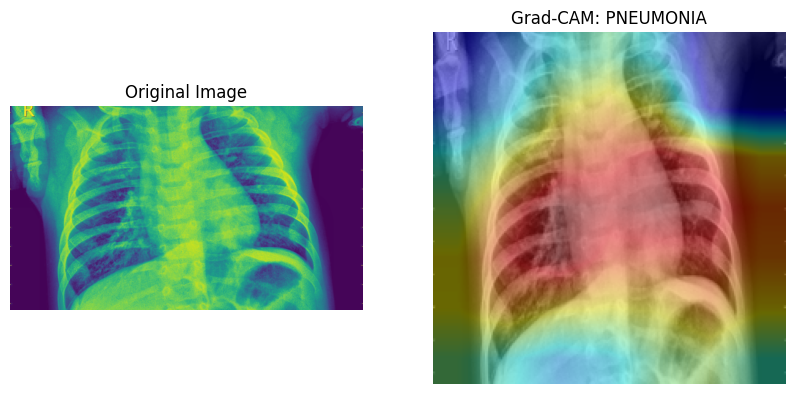

NORMAL: 0.00%
PNEUMONIA: 99.99%
Predicted: PNEUMONIA with confidence 99.99%


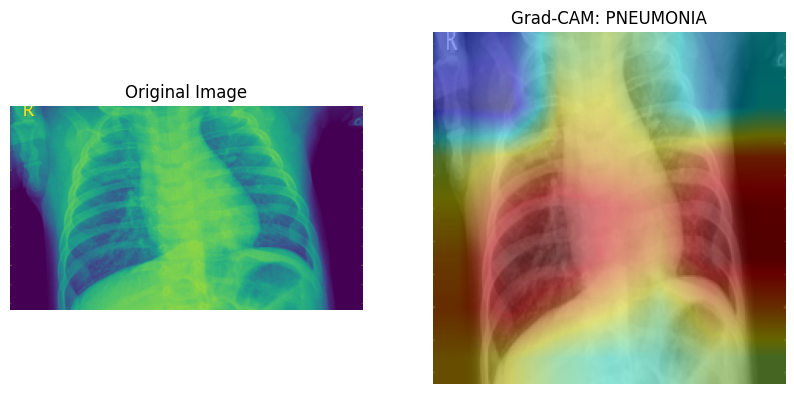

NORMAL: 0.00%
PNEUMONIA: 100.00%
Predicted: PNEUMONIA with confidence 100.00%


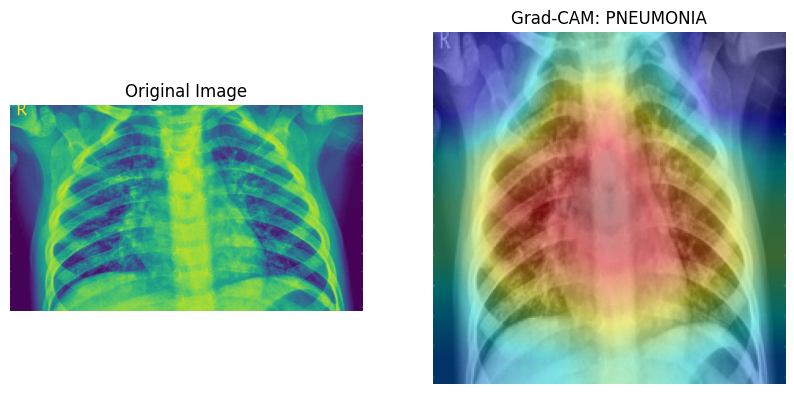

NORMAL: 0.00%
PNEUMONIA: 100.00%
Predicted: PNEUMONIA with confidence 100.00%


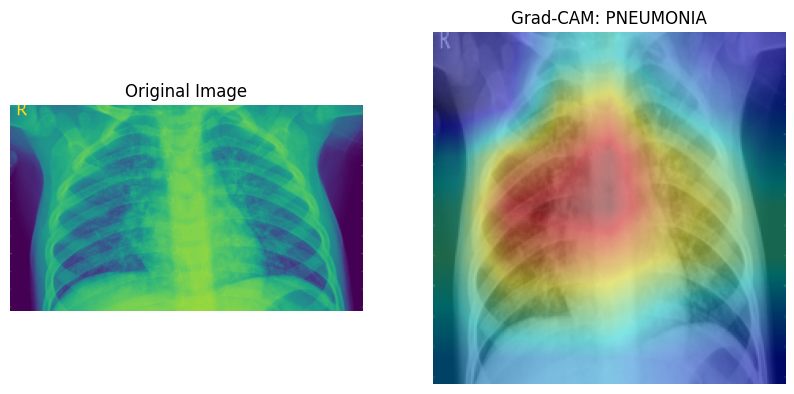

NORMAL: 0.00%
PNEUMONIA: 100.00%
Predicted: PNEUMONIA with confidence 100.00%


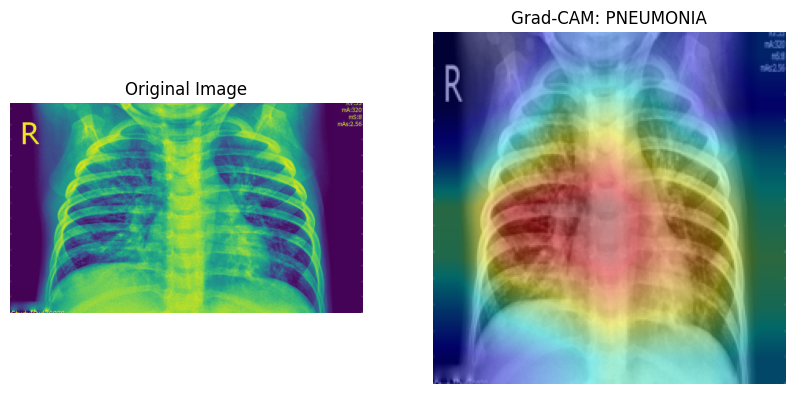

NORMAL: 0.00%
PNEUMONIA: 100.00%
Predicted: PNEUMONIA with confidence 100.00%


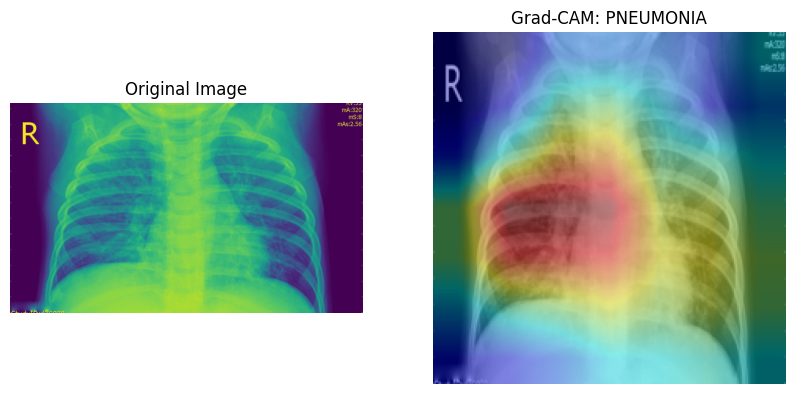

In [ ]:
# Load the model
model = models.densenet121(pretrained=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load(SAVED_MODEL_PATH, map_location=device))
model.to(device)
model.eval()

class_names = ["NORMAL", "PNEUMONIA"]

def DCE(pil_image):
    # Convert PIL image to grayscale NumPy array
    gray = np.array(pil_image.convert("L"))

    # Apply CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl1 = clahe.apply(gray)

    # Convert back to PIL RGB for the model
    cl1_rgb = cv2.cvtColor(cl1, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(cl1_rgb)

def generate_heatmap(model, input_tensor, target_class):
  #Generate Grad-cam heatmap for the given model and image tensor
  #Hook the activations and gradients from the last convolutional layer
  gradients = []
  activations = []

  def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0].detach())

  def forward_hook(module, input, output):
    activations.append(output.detach())

  #Register hooks on the last conv layer
  target_layer = model.features[-1]
  forward_handle = target_layer.register_forward_hook(forward_hook)
  backward_handle = target_layer.register_backward_hook(backward_hook)

  #forward pass
  output = model(input_tensor)
  model.zero_grad()
  class_score = output[0, target_class]
  class_score.backward()

  #Get hooked data
  grads = gradients[0]
  acts = activations[0]

  #Global average pooling
  weights = grads.mean(dim=(2,3), keepdim=True)
  cam = (weights * acts).sum(dim=1, keepdim=True)
  cam = F.relu(cam)

  #Normalize the heatmap
  cam = cam.squeeze().cpu().numpy()
  cam = cv2.resize(cam, (224, 224))
  cam = cam - np.min(cam)
  cam = cam / np.max(cam)

  #Clean up hooks
  forward_handle.remove()
  backward_handle.remove()

  return cam

def overlay_heatmap(img, heatmap):
  #Overlay heatmap on the original image
  heatmap = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
  img = np.array(img)
  img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
  overlay = cv2. addWeighted(heatmap, 0.4, img, 0.6, 0)
  return cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)


def IdentifyImage(img_path, dynamicEnhance):
# Same img transform
  fixed_transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.Grayscale(num_output_channels=3),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5])
  ])

  # Load and preprocess outside image
  image = Image.open(img_path).convert("L")

  if dynamicEnhance:
    image = DCE(image)
    image = image.convert("L")

  input_tensor = fixed_transform(image).unsqueeze(0).to(device)
  input_tensor.requires_grad_()

  # Get prediction
  output = model(input_tensor)
  probabilities = F.softmax(output, dim=1)[0]
  _, predicted = torch.max(probabilities, 0)

  # Print results
  # print(enumerate(probabilities))
  # print("Probabilities:", probabilities)
  # print("Class names:", class_names)

  for i, prob in enumerate(probabilities):
      if i < len(class_names):
        print(f"{class_names[i]}: {prob.item() * 100:.2f}%")

  print(f"Predicted: {class_names[predicted.item()]} with confidence {probabilities[predicted].item() * 100:.2f}%")

  #Generate and display Grad-cam heatmap
  heatmap = generate_heatmap(model, input_tensor, predicted.item())
  overlay = overlay_heatmap(image.resize((224, 224)), heatmap)

  plt.figure(figsize=(10, 5))
  plt.subplot(1, 2, 1)
  plt.title("Original Image")
  plt.imshow(image)
  plt.axis("off")

  plt.subplot(1, 2, 2)
  plt.title(f"Grad-CAM: {class_names[predicted.item()]}")
  plt.imshow(overlay)
  plt.axis("off")

  plt.show()

IdentifyImage(test_image, True)
IdentifyImage(test_image, False)

IdentifyImage(test_image2, True)
IdentifyImage(test_image2, False)

IdentifyImage(test_image3, True)
IdentifyImage(test_image3, False)

IdentifyImage(test_image4, True)
IdentifyImage(test_image4, False)

IdentifyImage(test_image5, True)
IdentifyImage(test_image5, False)

IdentifyImage(test_image6, True)
IdentifyImage(test_image6, False)

IdentifyImage(test_image7, True)
IdentifyImage(test_image7, False)

In [ ]:

# -----------------------------
# Load model
# -----------------------------
model = models.resnet50(pretrained=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.fc = nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/content/drive/MyDrive/ResNet18 Model and Testing Images/ResNet50model_prototype.pth", map_location=device))
model.to(device)
model.eval()

class_names = ["NORMAL", "PNEUMONIA"]

# -----------------------------
# Dynamic Contrast Enhancement (CLAHE)
# -----------------------------
def DCE(pil_image):
    gray = np.array(pil_image.convert("L"))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced = clahe.apply(gray)
    return Image.fromarray(enhanced, mode="L")

# -----------------------------
# Grad-CAM heatmap
# -----------------------------
def generate_heatmap(model, input_tensor, target_class):
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0].detach())

    def forward_hook(module, input, output):
        activations.append(output.detach())

    target_layer = model.features[-1]   

    f_handle = target_layer.register_forward_hook(forward_hook)
    b_handle = target_layer.register_backward_hook(backward_hook)

    input_tensor.requires_grad_()
    output = model(input_tensor)
    model.zero_grad()
    class_score = output[0, target_class]
    class_score.backward()

    grads = gradients[0]
    acts = activations[0]

    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = F.relu(cam)

    cam = cam.squeeze().cpu().numpy()
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    f_handle.remove()
    b_handle.remove()
    return cam

# -----------------------------
# Overlay grayscale heatmap
# -----------------------------
def overlay_heatmap(img, heatmap):
    img_gray = np.array(img.convert("L"), dtype=np.float32) / 255.0
    heat = cv2.resize(heatmap, (img_gray.shape[1], img_gray.shape[0]))
    overlay = 0.6 * img_gray + 0.4 * heat
    overlay = np.clip(overlay, 0, 1)
    overlay_img = Image.fromarray(np.uint8(overlay * 255), mode="L")
    return overlay_img

# -----------------------------
# Main identification function
# -----------------------------
def IdentifyImage(pil_image, dynamicEnhance=True):

    if dynamicEnhance:
        pil_image = DCE(pil_image)

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

    input_tensor = transform(pil_image).unsqueeze(0).to(device)
    output = model(input_tensor)
    probabilities = F.softmax(output, dim=1)[0]
    _, predicted = torch.max(probabilities, 0)

    heatmap = generate_heatmap(model, input_tensor, predicted.item())
    overlay = overlay_heatmap(pil_image.resize((224, 224)), heatmap)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(pil_image, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title(f"Grad-CAM: {class_names[predicted.item()]}")
    plt.imshow(overlay, cmap="gray")
    plt.axis("off")
    plt.show()

    return f"{class_names[predicted.item()]} ({probabilities[predicted].item() * 100:.2f}%)"

# -----------------------------
# Gradio Interface
# -----------------------------
with gr.Blocks() as demo:
    gr.Markdown("### PneuVision Interface (Grayscale Mode)")

    with gr.Row():
        img = gr.Image(label="Upload X-Ray")
        apply_dce = gr.Checkbox(label="Apply Dynamic Contrast Enhancement (DCE)", value=True)

    output = gr.Textbox(label="Prediction")
    btn = gr.Button("Analyze")

    btn.click(fn=IdentifyImage, inputs=[img, apply_dce], outputs=[output])

demo.launch(share=True, debug=True)

# -----------------------------
# Optional: direct testing
# -----------------------------
# IdentifyImage("/content/drive/MyDrive/ResNet18 Model and Testing Images/Healthy Lung 2.jpg", True)


In [ ]:
# # First let's update all the packages to the latest ones with the following command
# !sudo apt update -qq

# # Now we want to install some prerequisite packages which will let us use HTTPS over apt
# !sudo apt install apt-transport-https ca-certificates curl software-properties-common -qq

# # After that we will add the GPG key for the official Docker repository to the system
# !curl -fsSL https://download.docker.com/linux/ubuntu/gpg | sudo apt-key add -

# # We will add the Docker repository to our APT sources
# !sudo add-apt-repository "deb [arch=amd64] https://download.docker.com/linux/ubuntu bionic stable"

# # Next let's update the package database with our newly added Docker package repo
# !sudo apt update -qq

# # Finally lets install docker with the below command
# !sudo apt install docker-ce

# # Lets check that docker is running
# !docker

31 packages can be upgraded. Run 'apt list --upgradable' to see them.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
ca-certificates is already the newest version (20240203~22.04.1).
curl is already the newest version (7.81.0-1ubuntu1.21).
software-properties-common is already the newest version (0.99.22.9).
apt-transport-https is already the newest version (2.4.14).
0 upgraded, 0 newly installed, 0 to remove and 31 not upgraded.
OK
Repository: 'deb [arch=amd64] https://download.docker.com/linux/ubuntu bionic stable'
Description:
Archive for codename: bionic components: stable
More info: https://download.docker.com/linux/ubuntu
Adding repository.
Press [ENTER] to continue or Ctrl-c to cancel.
Adding deb entry to /etc/apt/sources.list.d/archive_uri-https_download_docker_com_linux_ubuntu-jammy.list
Adding disabled deb-src entry to /etc/apt/sources.